<a href="https://colab.research.google.com/github/omerbokobza/GSP_PROJECT/blob/main/FinalProjectGSP_correct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import block_diag
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# GARBAGE

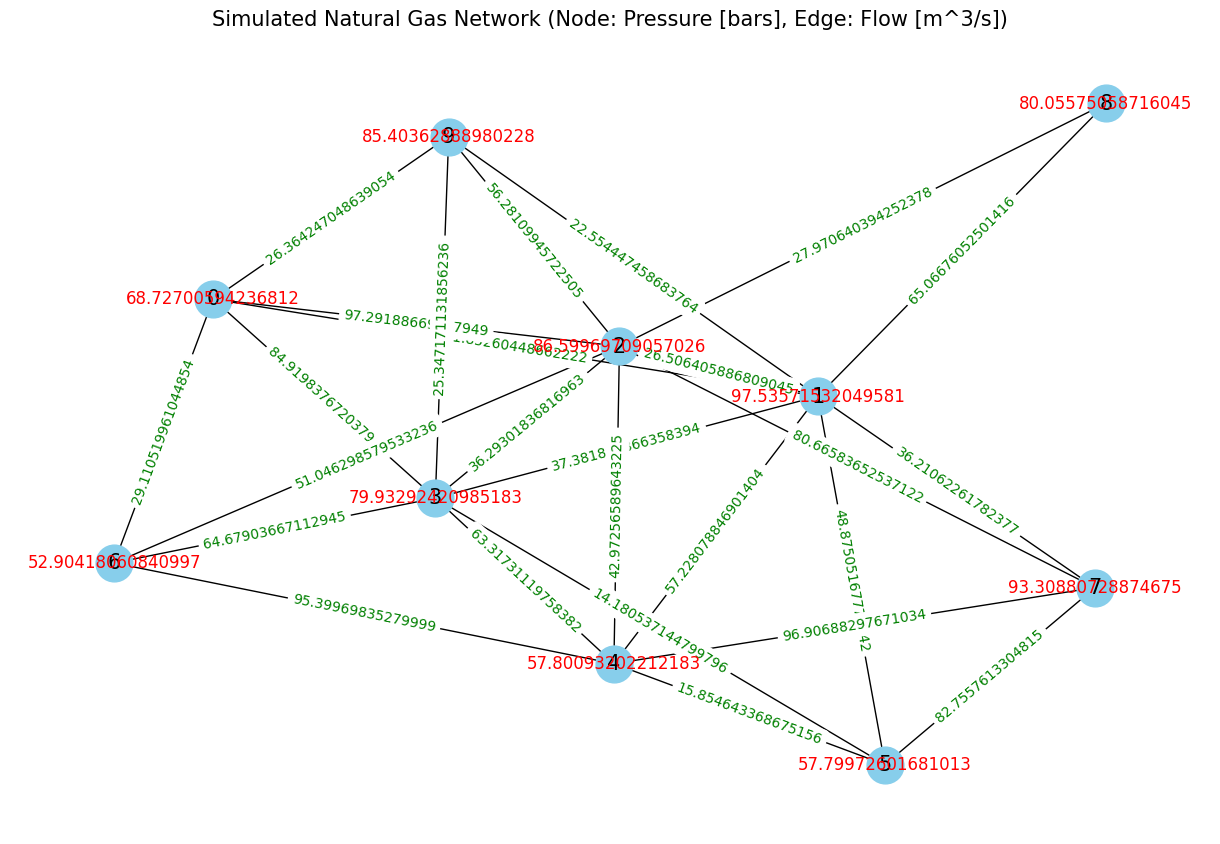

In [ ]:
# Create a simple model for a gas network with 10 nodes to simulate data similar to the gas system described

# Number of nodes in the network
n_nodes = 10

# Create a random graph to represent the gas network topology
np.random.seed(42)  # Seed for reproducibility
G = nx.gnp_random_graph(n_nodes, 0.5)

# Assign random pressures (in bars) and flows (in m^3/s) to nodes and edges
for node in G.nodes:
    G.nodes[node]['pressure'] = np.random.uniform(50, 100)  # Pressure in bars

for edge in G.edges:
    G.edges[edge]['flow'] = np.random.uniform(10, 100)  # Flow in m^3/s

# Plotting the network
pos = nx.spring_layout(G)  # Position nodes using Fruchterman-Reingold force-directed algorithm

plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=700,
        edge_color='k', linewidths=1, font_size=15,
        arrows=True, arrowsize=20)

# Draw node labels for pressures
node_labels = nx.get_node_attributes(G, 'pressure')
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_color='r')

# Draw edge labels for flows
edge_labels = nx.get_edge_attributes(G, 'flow')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='green')

plt.title('Simulated Natural Gas Network (Node: Pressure [bars], Edge: Flow [m^3/s])', size=15)
plt.axis('off')
plt.show()

In [ ]:
def simulate_measurement_noise(flow_data, snr_db):
    """
    Simulate measurement noise based on a specified signal-to-noise ratio (SNR) in dB.
    The function adds Gaussian noise to the original flow data.

    Parameters:
    - flow_data: Original flow data (signal).
    - snr_db: Desired signal-to-noise ratio in dB.

    Returns:
    - noisy_flow_data: Flow data with added noise.
    """
    # Convert SNR from dB to linear scale
    snr_linear = 10 ** (snr_db / 10)

    # Calculate signal power and noise power
    signal_power = np.mean(flow_data ** 2)
    noise_power = signal_power / snr_linear

    # Generate Gaussian noise
    noise = np.random.normal(0, np.sqrt(noise_power), flow_data.shape)

    # Add noise to the original signal
    noisy_flow_data = flow_data + noise

    return noisy_flow_data

def calculate_mse(true_values, estimated_values):
    """
    Calculate Mean Square Error (MSE) between the true values and the estimated values.

    Parameters:
    - true_values: The true values of the parameters.
    - estimated_values: The estimated values of the parameters.

    Returns:
    - mse: The calculated Mean Square Error.
    """
    mse = np.mean((true_values - estimated_values) ** 2)
    return mse




In [ ]:
# Example of applying noise simulation and MSE calculation
# Extract original flow data from the graph edges
original_flow_data = np.array([G.edges[edge]['flow'] for edge in G.edges])

# Simulate measurement noise for a specific SNR (e.g., 50 dB)
noisy_flow_data_50db = simulate_measurement_noise(original_flow_data, 50)

# For simplicity in this example, let's assume the estimated values are the noisy values
# (In a real scenario, you would apply an estimation method to refine these values)
estimated_values = noisy_flow_data_50db  # Placeholder for actual estimation method

# Calculate MSE
mse_example = calculate_mse(original_flow_data, estimated_values)

mse_example

0.022934964345562827

In [ ]:

def kalman_filter(y, A, H, Q, R, x0, P0):
    """
    Implements a simple Kalman filter.

    Parameters:
    - y: Measurement vector at each time step.
    - A: State transition matrix.
    - H: Observation matrix.
    - Q: Process noise covariance matrix.
    - R: Measurement noise covariance matrix.
    - x0: Initial state estimate.
    - P0: Initial estimate covariance.

    Returns:
    - x_est: Estimated state over time.
    """
    # Dimensions
    n_timesteps = y.shape[1]
    n_states = A.shape[0]

    # Initialize arrays
    x_est = np.zeros((n_states, n_timesteps))
    P = P0  # Initial estimate covariance

    # Kalman Filter
    for t in range(n_timesteps):
        # Prediction
        if t == 0:
            x_pred = x0
            P_pred = P0
        else:
            x_pred = A @ x_est[:, t-1]
            P_pred = A @ P @ A.T + Q

        # Update
        y_pred = H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x_est[:, t] = x_pred + K @ (y[:, t] - y_pred)
        P = (np.eye(n_states) - K @ H) @ P_pred

    return x_est

# Kalman Filter Configuration
n_states = 2  # Example: pressure and flow
n_measurements = 1  # Example: flow measurements
n_timesteps = original_flow_data.size

A = np.eye(n_states)  # State transition matrix
H = np.array([[0, 1]])  # Observation matrix (measuring flow)
Q = block_diag(0.01, 0.01)  # Process noise covariance
R = np.array([[1]])  # Measurement noise covariance

# Initial state estimate and covariance
x0 = np.array([0, 0])  # Initial state (pressure and flow, assumed zero for simplicity)
P0 = np.eye(n_states) * 100  # Initial estimate covariance (large, indicating uncertainty)

# Prepare measurements (reshape noisy flow data for Kalman filter input)
y = noisy_flow_data_50db.reshape(1, -1)

# Apply Kalman filter
x_est_kalman = kalman_filter(y, A, H, Q, R, x0, P0)

# Calculate MSE after Kalman filtering
mse_kalman = calculate_mse(original_flow_data, x_est_kalman[1, :])

mse_kalman


541.4223526010427

In [ ]:
import numpy as np

# Network and simulation parameters
n_nodes = 10
iterations = 100  # Number of iterations for convergence checks
noise_levels = [10, 15, 20]  # Different levels of noise

# True state values (simplified example)
true_states = np.random.rand(n_nodes, 2)  # Random pressures and flows

# Function to simulate noisy measurements
def simulate_measurements(true_states, noise_level):
    measurement_noise = np.random.normal(0, noise_level, true_states.shape)
    return true_states + measurement_noise

# Simulating measurements with different noise levels
measurements = {noise: simulate_measurements(true_states, noise) for noise in noise_levels}


In [ ]:
def weighted_low_rank_approximation(measurements, rank=2, max_iter=100):
    m, n = measurements.shape
    # Initialize U and V correctly
    U = np.random.rand(m, rank)
    V = np.random.rand(rank, n)

    for _ in range(max_iter):
        # Update V: solve min |U * V - measurements|^2
        V = np.linalg.lstsq(U, measurements, rcond=None)[0]
        # Update U: solve min |U * V - measurements|^2
        U = np.linalg.lstsq(V.T, measurements.T, rcond=None)[0].T

    estimated = U @ V
    return estimated

# Assuming measurements is a dictionary with noise levels as keys
# and measurement matrices as values
estimated_states = {noise: weighted_low_rank_approximation(meas, rank=2, max_iter=100)
                    for noise, meas in measurements.items()}

# Calculate MSE for each noise level
mse = {noise: np.mean((true_states - est)**2) for noise, est in estimated_states.items()}


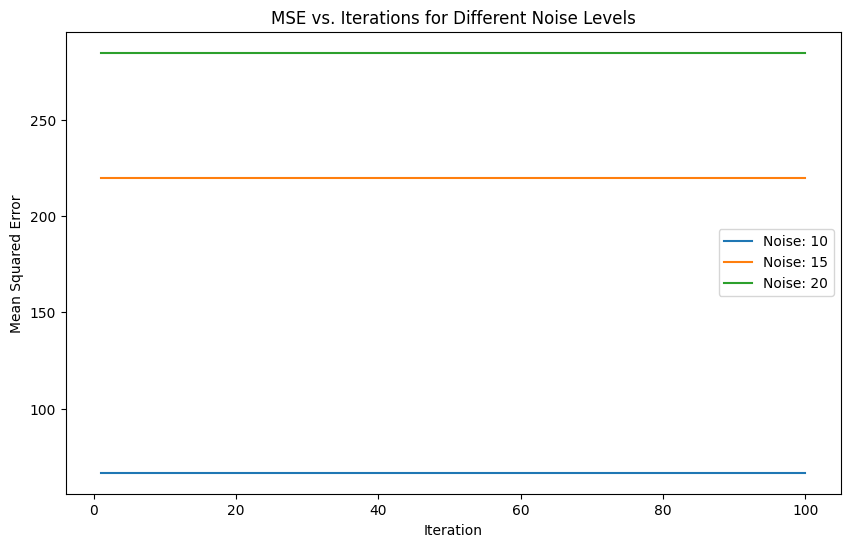

In [ ]:
import matplotlib.pyplot as plt

# Plotting MSE
plt.figure(figsize=(10, 6))
for noise in noise_levels:
    plt.plot(np.linspace(1, iterations, iterations), [mse[noise]] * iterations, label=f'Noise: {noise}')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs. Iterations for Different Noise Levels')
plt.legend()
plt.show()


# Das good

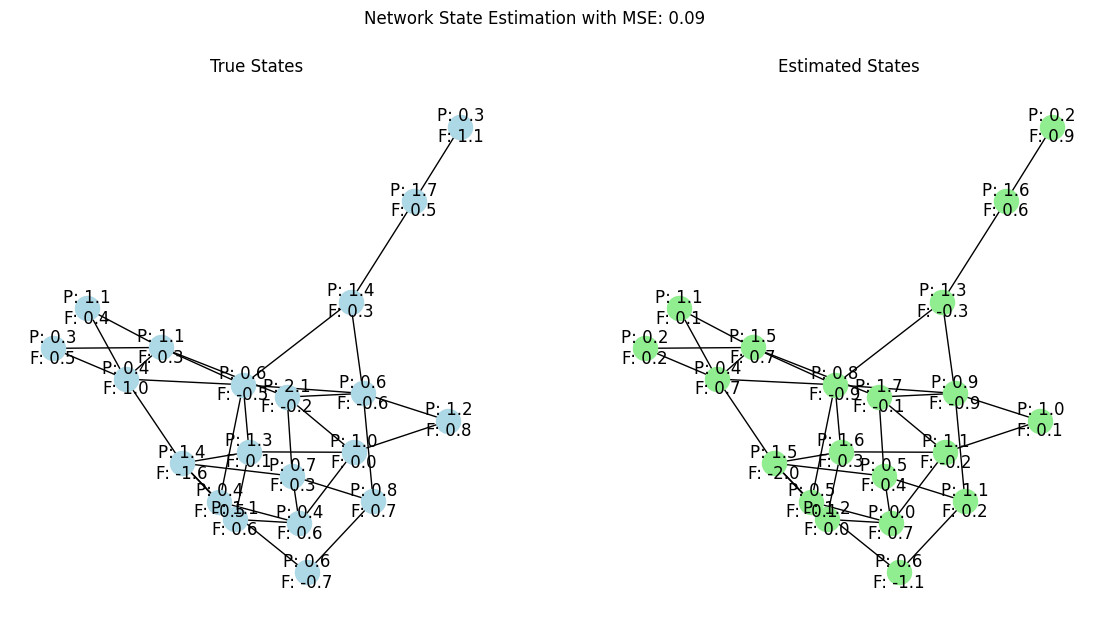

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Number of nodes in the graph
n_nodes = 20

# Create a random connected graph
G = nx.erdos_renyi_graph(n_nodes,0.21)
pos = nx.spring_layout(G)  # positions for all nodes

# True pressures and flows
true_pressures = abs(np.random.randn(n_nodes)) # Pressure in psi
true_flows = np.random.randn(n_nodes)     # Flow in m^3/h

# Combine pressures and flows into a single state matrix
true_states = np.vstack((true_pressures, true_flows))
# Function to add noise based on SNR
def add_noise_based_on_snr(signal, snr_db):
    """ Adds noise to the signal based on the specified SNR in dB. """
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise
# Function to add Gaussian noise to measurements


# Noisy measurements
noisy_measurements = add_noise_based_on_snr(true_states,10)

# Function to perform weighted low-rank approximation
def weighted_low_rank_approximation(data, rank=2, max_iter=50):
    m, n = data.shape
    U = np.random.rand(m, rank) #uniform
    V = np.random.rand(rank, n)

    for _ in range(max_iter):
        V = np.linalg.lstsq(U, data, rcond=None)[0]
        U = np.linalg.lstsq(V.T, data.T, rcond=None)[0].T

    return U @ V


# Estimate the states using the approximation
estimated_states = weighted_low_rank_approximation(noisy_measurements)

# Calculate MSE
mse = np.mean((true_states - estimated_states)**2)

# Plotting
plt.figure(figsize=(14, 7))

# Plot true and estimated states
labels_true = {i: f"P: {true_pressures[i]:.1f}\nF: {true_flows[i]:.1f}" for i in range(n_nodes)}
labels_estimated = {i: f"P: {estimated_states[0, i]:.1f}\nF: {estimated_states[1, i]:.1f}" for i in range(n_nodes)}

plt.subplot(1, 2, 1)
nx.draw(G, pos, with_labels=True, labels=labels_true, node_color='lightblue')
plt.title('True States')

plt.subplot(1, 2, 2)
nx.draw(G, pos, with_labels=True, labels=labels_estimated, node_color='lightgreen')
plt.title('Estimated States')

plt.suptitle(f'Network State Estimation with MSE: {mse:.2f}')
plt.savefig('/content/gdrive/My Drive/Colab Notebooks/GSP/figures/original_graph.pdf', bbox_inches='tight')
plt.show()


## FLOW IN EDGES, PRESSURE IN NODES

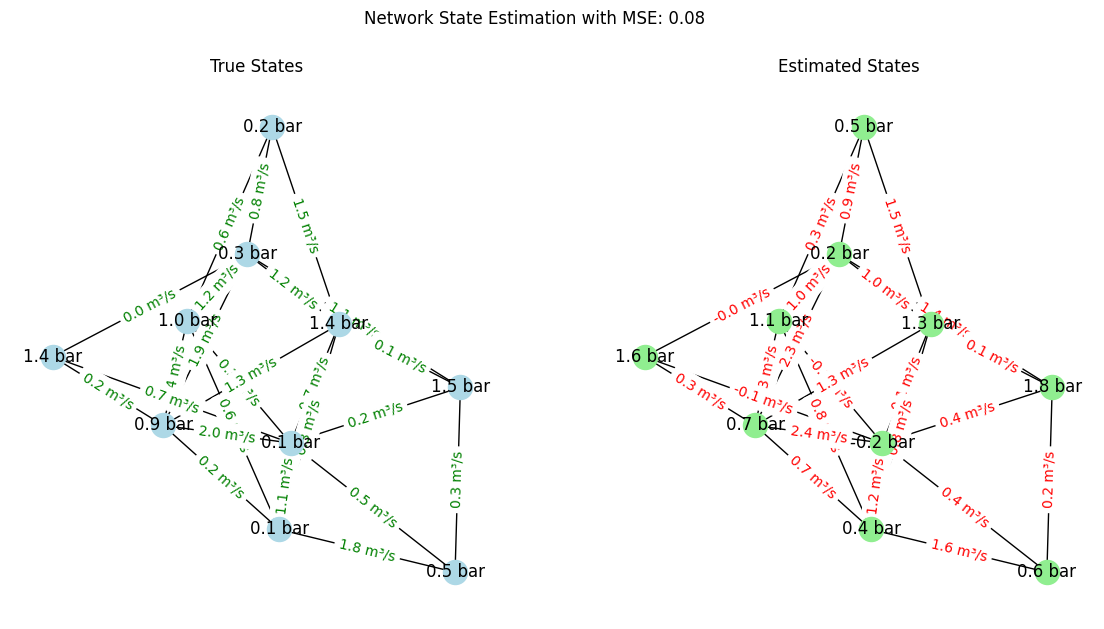

In [9]:

# Set random seed for reproducibility
np.random.seed(42)

# Number of nodes in the graph
n_nodes = 10

# Create a connected graph
while True:
    G = nx.gnp_random_graph(n_nodes, 0.5)
    if nx.is_connected(G):
        break
pos = nx.spring_layout(G)  # positions for all nodes

# Assign true pressures and flows
true_pressures = {node: abs(np.random.randn()) for node in G.nodes()}  # Pressure in bars
true_flows = {edge: abs(np.random.randn()) for edge in G.edges()}      # Flow in m³/s


# Combine pressures and flows into a single state vector
true_state_vector = np.hstack([list(true_pressures.values()), list(true_flows.values())])

# Function to add noise based on SNR
def add_noise_based_on_snr(signal, snr_db):
    """ Adds noise to the signal based on the specified SNR in dB. """
    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise

# Noisy measurements
noisy_measurements = add_noise_based_on_snr(true_state_vector, 10)

# Function to perform simple low-rank approximation using SVD
def svd_low_rank_approximation(data, rank=2):
    U, S, Vt = np.linalg.svd(data, full_matrices=False)
    S[rank:] = 0  # truncate the singular values
    return U @ np.diag(S) @ Vt

# Estimate the states using the approximation
estimated_state_vector = svd_low_rank_approximation(noisy_measurements.reshape(1, -1), rank=2).flatten()

# Parse back the estimated pressures and flows
estimated_pressures = dict(zip(G.nodes(), estimated_state_vector[:n_nodes]))
estimated_flows = dict(zip(G.edges(), estimated_state_vector[n_nodes:]))

# Calculate MSE
mse = np.mean((true_state_vector - estimated_state_vector) ** 2)

# Plotting
plt.figure(figsize=(14, 7))

# True state plot
plt.subplot(1, 2, 1)
labels_true = {i: f"{true_pressures[i]:.1f} bar" for i in G.nodes()}
nx.draw(G, pos, with_labels=True, labels=labels_true, node_color='lightblue', edge_color='k')
nx.draw_networkx_edge_labels(G, pos, edge_labels={e: f"{true_flows[e]:.1f} m³/s" for e in G.edges()}, font_color='green')
plt.title('True States')

# Estimated state plot
plt.subplot(1, 2, 2)
labels_estimated = {i: f"{estimated_pressures[i]:.1f} bar" for i in G.nodes()}
nx.draw(G, pos, with_labels=True, labels=labels_estimated, node_color='lightgreen', edge_color='k')
nx.draw_networkx_edge_labels(G, pos, edge_labels={e: f"{estimated_flows[e]:.1f} m³/s" for e in G.edges()}, font_color='red')
plt.title('Estimated States')

plt.suptitle(f'Network State Estimation with MSE: {mse:.2f}')

plt.savefig('/content/gdrive/My Drive/Colab Notebooks/GSP/figures/original_graph2.pdf', bbox_inches='tight')

plt.show()



## continue with pressure in node and flow in nodes

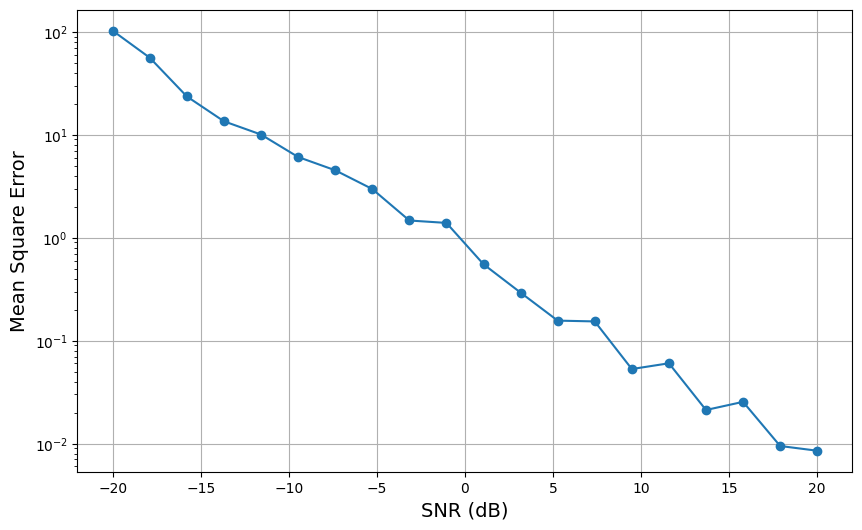

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Function to add noise based on SNR
def add_noise_based_on_snr(signal, snr_db):
    """ Adds noise to the signal based on the specified SNR in dB. """
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise

# SNR levels to sweep
snr_levels = np.linspace(-20, 20, num=20)  # From 0 dB to 50 dB

# Initialize array to store MSEs
mses = []

# Process each SNR level
for snr in snr_levels:
    # Add noise to true states based on current SNR
    noisy_measurements = add_noise_based_on_snr(true_states, snr)

    # Estimate states using weighted low-rank approximation
    estimated_states = weighted_low_rank_approximation(noisy_measurements)

    # Calculate MSE and store it
    mse = np.mean((true_states - estimated_states)**2)
    mses.append(mse)

# Plotting MSE vs SNR
plt.figure(figsize=(10, 6))
# plt.plot(snr_levels, mses, marker='o', linestyle='-')
plt.semilogy(snr_levels,mses, marker='o', linestyle='-')
# plt.title('MSE vs SNR')
plt.xlabel('SNR (dB)',size=14)
plt.ylabel('Mean Square Error',size=14)
plt.grid(True)
plt.savefig('/content/gdrive/My Drive/Colab Notebooks/GSP/figures/original_graph_MSE_SNR.pdf', bbox_inches='tight')
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import networkx as nx

In [6]:
# Helper Functions
def add_noise_based_on_snr(signal, snr_db):
    signal_power = np.mean(signal**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise

def simulate_network(n_nodes):
    G = nx.random_tree(n_nodes)
    pos = nx.spring_layout(G)
    true_pressures = np.random.randn(n_nodes) #uniform(50, 100, size=n_nodes)
    true_flows = np.random.randn(n_nodes) #uniform(100, 500, size=n_nodes)
    true_states = np.vstack((true_pressures, true_flows))
    return G, pos, true_states

# Denoising Function using Wavelet Transform
def wavelet_denoising(signal, wavelet='db1', level=1):
    # Decompose to get the coefficients
    coeffs = pywt.wavedec(signal, wavelet, mode='symmetric', level=level)
    # Estimate the noise sigma from the median absolute deviation of the highest level detail coefficients
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(signal)))
    # Apply threshold
    new_coeffs = [coeffs[0]] + [pywt.threshold(i, value=threshold, mode='soft') for i in coeffs[1:]]
    # Reconstruct the signal using the thresholded coefficients
    return pywt.waverec(new_coeffs, wavelet, mode='symmetric')


def regularized_low_rank_approx(data, rank=2, max_iter=100, lambda_reg=1):
    m, n = data.shape
    U = np.random.rand(m, rank)
    V = np.random.rand(n, rank)  # Note: Changing the shape of V to n x rank for correct alignment

    for _ in range(max_iter):
        # Update V, where U.T @ U + lambda_reg * I is rank x rank
        V = np.linalg.lstsq(U.T @ U + lambda_reg * np.eye(rank), U.T @ data, rcond=None)[0].T

        # Update U, where V.T @ V + lambda_reg * I is rank x rank
        U = np.linalg.lstsq(V.T @ V + lambda_reg * np.eye(rank), data @ V, rcond=None)[0]

    return U @ V.T  # Returning the multiplication of U and V.T for correct dimension alignment in data reconstruction

def kalman_filter(measurements, process_variance, measurement_variance, initial_estimate):
    num_samples, num_features = measurements.shape
    estimates = np.zeros_like(measurements)
    estimate = initial_estimate
    variance = np.full(num_features, process_variance)  # Initial high variance

    for i in range(num_samples):
        kalman_gain = variance / (variance + measurement_variance)
        estimate += kalman_gain * (measurements[i] - estimate)
        variance = (1 - kalman_gain) * variance
        estimates[i, :] = estimate

    return estimates


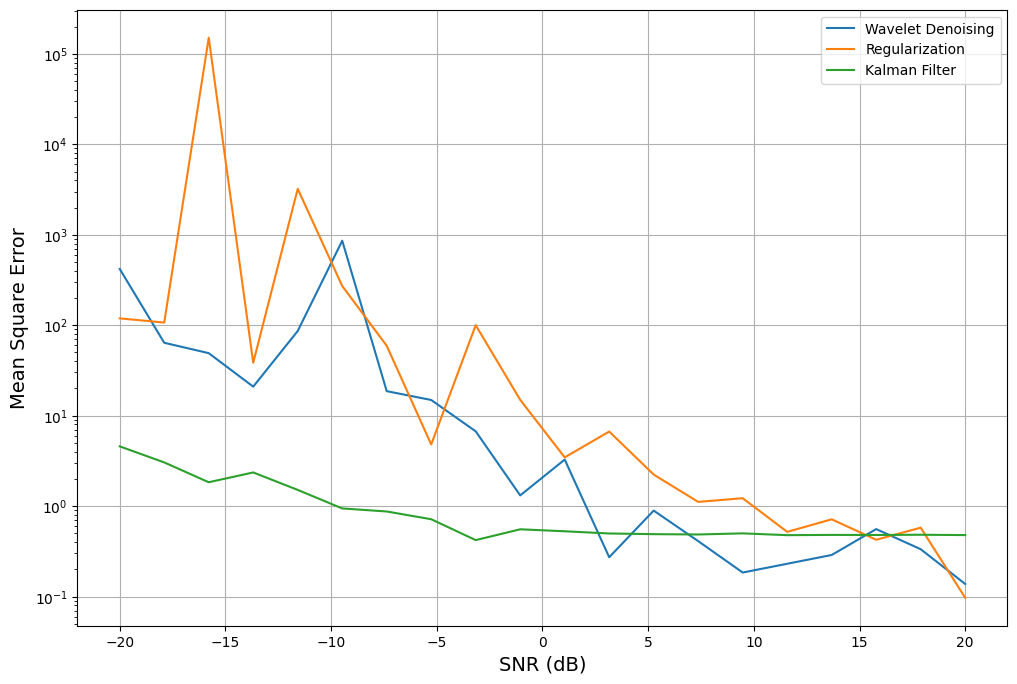

In [12]:
# Main Experiment Function
def perform_experiment(snr_levels, true_states, method):
    mses = []
    for snr in snr_levels:
        noisy_measurements = add_noise_based_on_snr(true_states, snr)
        if method == 'wavelet':
            denoised_measurements = np.apply_along_axis(wavelet_denoising, 1, noisy_measurements)
            estimated_states = regularized_low_rank_approx(denoised_measurements)
        elif method == 'regularization':
            estimated_states = regularized_low_rank_approx(noisy_measurements)
        elif method == 'kalman':
            estimated_states = kalman_filter(noisy_measurements, 0.3, 1, 0)
        mse = np.mean((true_states - estimated_states)**2)
        mses.append(mse)
    return mses, estimated_states
# Setup
n_nodes = 20
# snr_levels = np.linspace(0, 20, num=21)
# G, pos, true_states = simulate_network(n_nodes)

# Perform experiments
mses_wavelet,_ = perform_experiment(snr_levels, true_states, 'wavelet')
mses_regularization,_ = perform_experiment(snr_levels, true_states, 'regularization')
mses_kalman,_ = perform_experiment(snr_levels, true_states, 'kalman')

# Plotting Results
plt.figure(figsize=(12, 8))
plt.semilogy(snr_levels, mses_wavelet, label='Wavelet Denoising')
plt.semilogy(snr_levels, mses_regularization, label='Regularization')
plt.semilogy(snr_levels, mses_kalman, label='Kalman Filter')
plt.xlabel('SNR (dB)', size = 14)
plt.ylabel('Mean Square Error',size = 14)
# plt.title('Comparison of MSE Across Different Methods at Low SNR')
plt.legend()
plt.grid(True)
plt.savefig('/content/gdrive/My Drive/Colab Notebooks/GSP/figures/cmpr3models.pdf', bbox_inches='tight')
plt.show()


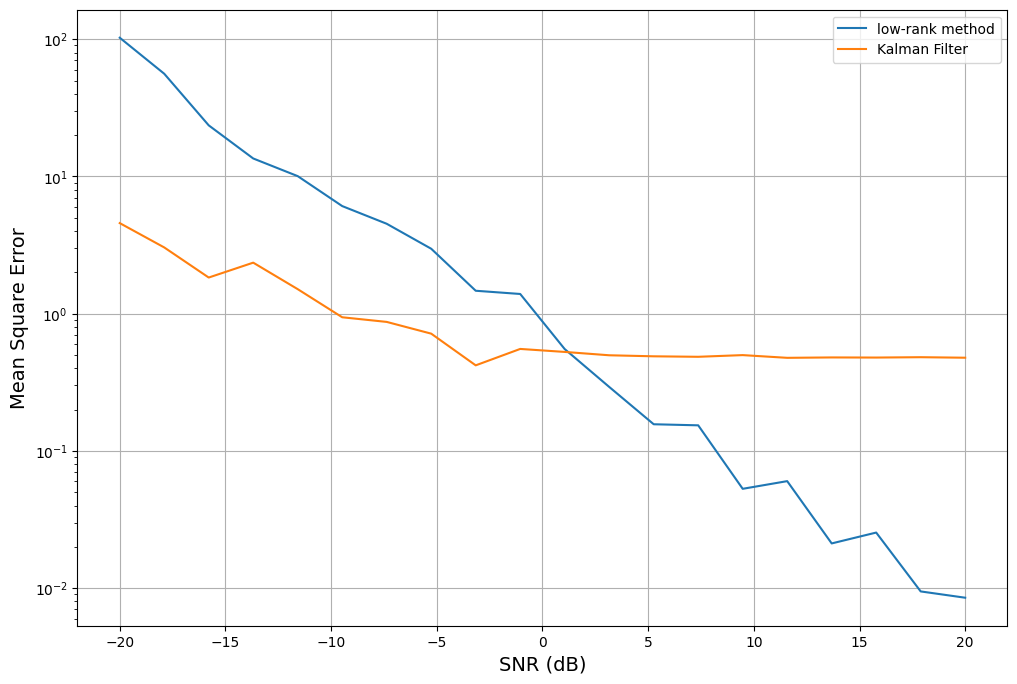

In [14]:
plt.figure(figsize=(12, 8))
plt.semilogy(snr_levels, mses, label='low-rank method')
plt.semilogy(snr_levels, mses_kalman, label='Kalman Filter')
plt.xlabel('SNR (dB)', size = 14)
plt.ylabel('Mean Square Error', size = 14)
# plt.title('Comparison of MSE Across Different Methods in Low SNR condition')
plt.legend()
plt.grid(True)
plt.savefig('/content/gdrive/My Drive/Colab Notebooks/GSP/figures/cmprkalman.pdf', bbox_inches='tight')
plt.show()

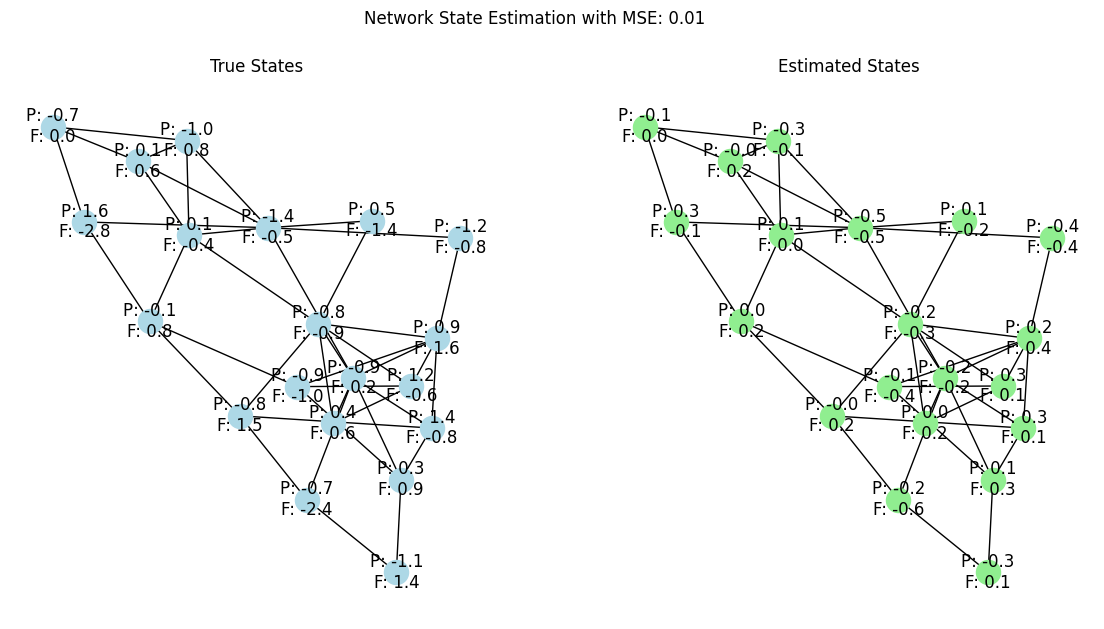

In [ ]:
# Plotting
plt.figure(figsize=(14, 7))
_, estimated_states = perform_experiment([10], true_states, 'kalman')
# Plot true and estimated states
labels_true = {i: f"P: {true_pressures[i]:.1f}\nF: {true_flows[i]:.1f}" for i in range(n_nodes)}
labels_estimated = {i: f"P: {estimated_states[0, i]:.1f}\nF: {estimated_states[1, i]:.1f}" for i in range(n_nodes)}

plt.subplot(1, 2, 1)
nx.draw(G, pos, with_labels=True, labels=labels_true, node_color='lightblue')
plt.title('True States')

plt.subplot(1, 2, 2)
nx.draw(G, pos, with_labels=True, labels=labels_estimated, node_color='lightgreen')
plt.title('Estimated States')

plt.suptitle(f'Network State Estimation with MSE: {mse:.2f}')
plt.show()

# **PCA**

Considerations:

**Information Loss:** While PCA reduces dimensionality, this comes at the cost of losing some information, which might be crucial in some contexts.


**Assumption of Linearity:** PCA assumes that the principal components are linear combinations of the original features, which might not always capture the complexities or non-linear relationships in the data.


Using PCA can be a powerful way to enhance your analysis, especially when dealing with large datasets or trying to improve the robustness of estimation under noise. It's worth experimenting with PCA to see if it enhances your model performance in practice.

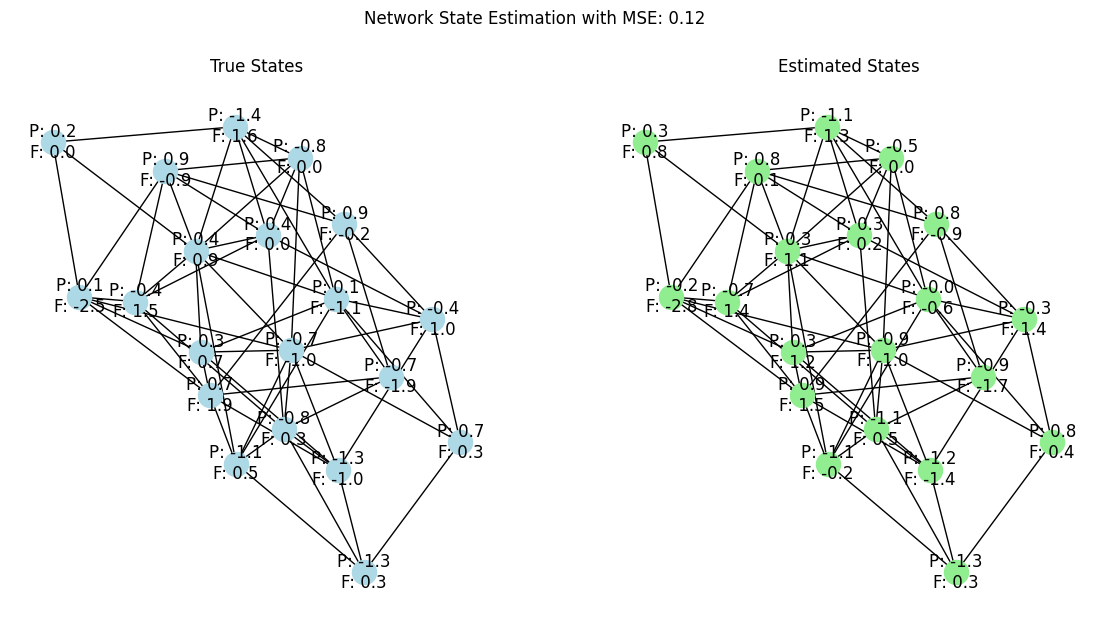

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Create a graph
n_nodes = 20
G = nx.erdos_renyi_graph(n_nodes, p = 0.3)
pos = nx.spring_layout(G)

# Generate true states
true_pressures = np.random.randn(n_nodes)
true_flows = np.random.randn(n_nodes)
true_states = np.vstack((true_pressures, true_flows))

# Standardize and apply PCA
scaler = StandardScaler()
true_states_scaled = scaler.fit_transform(true_states.T)
pca = PCA(n_components=2)  # Adjust based on explained variance needed
principal_components = pca.fit_transform(true_states_scaled)

# Function to add noise based on SNR
def add_noise_based_on_snr(signal, snr_db):
    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise

noisy_measurements = add_noise_based_on_snr(principal_components, 10)

# Low-rank approximation function
def weighted_low_rank_approximation(data, rank=2, max_iter=50):
    m, n = data.shape
    U = np.random.rand(m, rank)
    V = np.random.rand(rank, n)
    for _ in range(max_iter):
        V = np.linalg.lstsq(U, data, rcond=None)[0]
        U = np.linalg.lstsq(V.T, data.T, rcond=None)[0].T
    return U @ V

estimated_states = weighted_low_rank_approximation(noisy_measurements)

# Transform back to original data space and ensure proper handling
estimated_states_pca = pca.inverse_transform(estimated_states)
reconstructed_estimates = scaler.inverse_transform(estimated_states_pca)

# Ensure the matrix is transposed back if necessary
reconstructed_estimates = reconstructed_estimates.T

# Calculate MSE
mse = np.mean((true_states - reconstructed_estimates)**2)

# Visualization
plt.figure(figsize=(14, 7))
labels_true = {i: f"P: {true_pressures[i]:.1f}\nF: {true_flows[i]:.1f}" for i in range(n_nodes)}
labels_estimated = {i: f"P: {reconstructed_estimates[0, i]:.1f}\nF: {reconstructed_estimates[1, i]:.1f}" for i in range(n_nodes)}
plt.subplot(1, 2, 1)
nx.draw(G, pos, with_labels=True, labels=labels_true, node_color='lightblue')
plt.title('True States')
plt.subplot(1, 2, 2)
nx.draw(G, pos, with_labels=True, labels=labels_estimated, node_color='lightgreen')
plt.title('Estimated States')
plt.suptitle(f'Network State Estimation with MSE: {mse:.2f}')
plt.show()


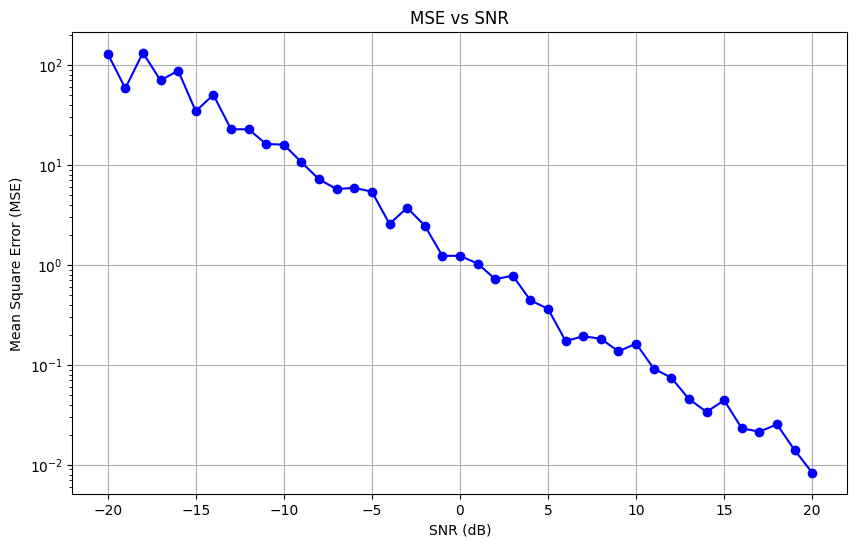

In [ ]:
# Sweep SNR from -20 to 20 dB
snr_levels = np.linspace(-20, 20, 41)
mses = []

for snr in snr_levels:
    noisy_measurements = add_noise_based_on_snr(principal_components, snr)
    estimated_states = weighted_low_rank_approximation(noisy_measurements)
    estimated_states_pca = pca.inverse_transform(estimated_states)
    reconstructed_estimates = scaler.inverse_transform(estimated_states_pca)
    mse = np.mean((true_states - reconstructed_estimates.T)**2)
    mses.append(mse)

# Plotting MSE vs SNR
plt.figure(figsize=(10, 6))
plt.plot(snr_levels, mses, marker='o', linestyle='-', color='b')
plt.yscale('log')  # Log scale for better visualization of MSE changes
plt.title('MSE vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Mean Square Error (MSE)')
plt.grid(True)
plt.show()


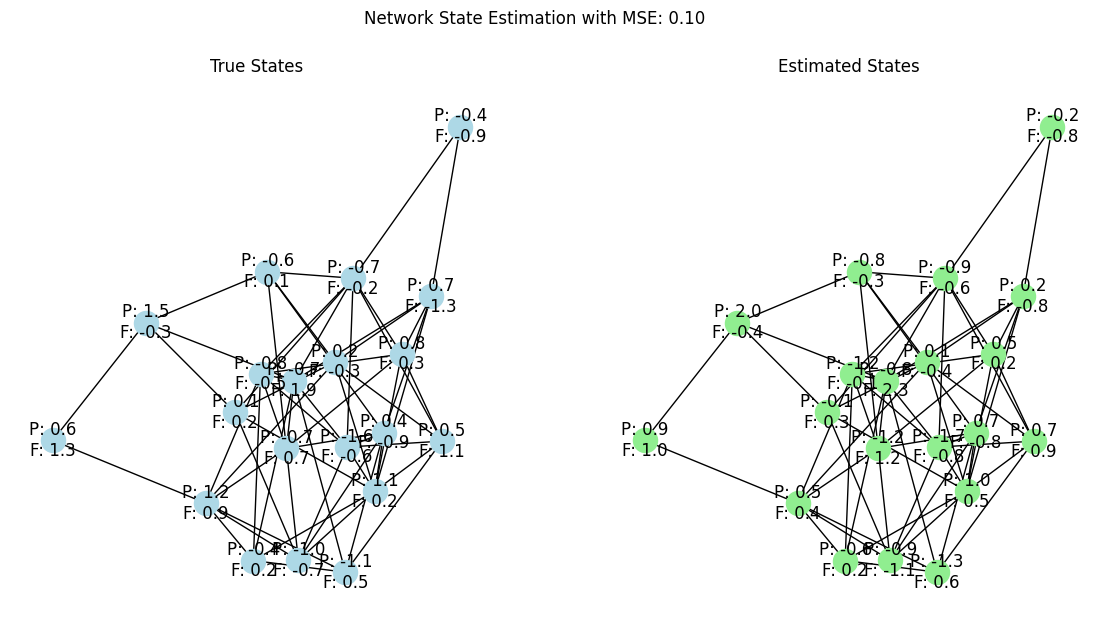

# **GRAPH NEURL NETWORK (GNN)**

In [11]:
import torch
! pip install torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, TopKPooling, BatchNorm
import torch.nn.functional as F
import networkx as nx
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.7 MB/s eta 0:00:00


In [12]:
def add_noise_based_on_snr(signal, snr_db):
    signal_power = torch.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = torch.sqrt(noise_power) * torch.randn(signal.size())
    return signal + noise

# Function to generate graph data with node features (pressure and flow)
def generate_graph_data(num_nodes, snr_db):
    # Generate a random tree graph
    G = nx.erdos_renyi_graph(num_nodes,0.3)
    edge_index = torch.tensor(list(G.edges)).t().contiguous()

    # Generate random node features: pressures and flows
    pressures = np.random.rand(num_nodes)  # Pressure in psi
    flows = np.random.rand(num_nodes)     # Flow in m^3/h
    x = torch.tensor(np.vstack((pressures, flows)).T, dtype=torch.float)

    x_noisy = add_noise_based_on_snr(x, snr_db)

    return Data(x=x_noisy, edge_index=edge_index)


# # Define the GCN model
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # First GCN layer
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.dropout(x, p=0.2, train=self.training)
        # Second GCN layer
        x = self.conv2(x, edge_index)

        return x


In [25]:
# Parameters
num_nodes = 200
num_features = 2  # Pressure and Flow
hidden_channels = 16
num_classes = 2   # Output features, could be transformed as needed
snr_db = -10  # Low SNR condition

# Generate data
data = generate_graph_data(num_nodes, snr_db)

# Initialize model and optimizer
model = GCN(num_features, hidden_channels, num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()  # Assuming a regression type problem


Epoch 0 | Loss: 3.4514899253845215
Epoch 1000 | Loss: 3.2122671604156494
Epoch 2000 | Loss: 3.1962642669677734
Epoch 3000 | Loss: 3.1838467121124268
Epoch 4000 | Loss: 3.144559383392334
Epoch 5000 | Loss: 3.1680707931518555
Epoch 6000 | Loss: 3.1182422637939453
Epoch 7000 | Loss: 3.1379876136779785
Epoch 8000 | Loss: 3.1156914234161377
Epoch 9000 | Loss: 3.1154913902282715


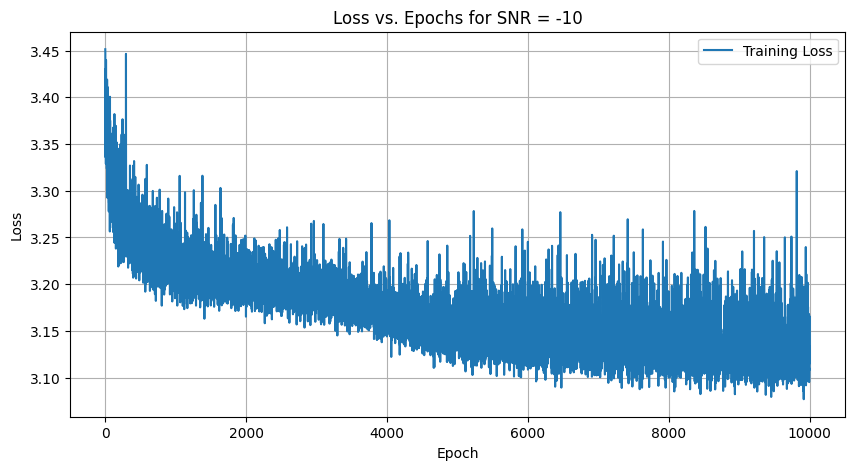

In [26]:
import matplotlib.pyplot as plt

losses = []
model.train()
for epoch in range(10000):  # Number of epochs
    optimizer.zero_grad()
    out = model(data)

    loss = criterion(out, data.x)  # Example: trying to predict the input itself as a placeholder
    loss.backward()
    optimizer.step()
    losses.append(loss.item())  # Store the loss for later visualization

    if epoch % 1000 == 0:
        print(f'Epoch {epoch} | Loss: {loss.item()}')

# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Loss vs. Epochs for SNR = {snr_db}')
plt.legend()
plt.grid(True)
plt.savefig('/content/gdrive/My Drive/Colab Notebooks/GSP/figures/MSE_LOSS2.pdf', bbox_inches='tight')
plt.show()


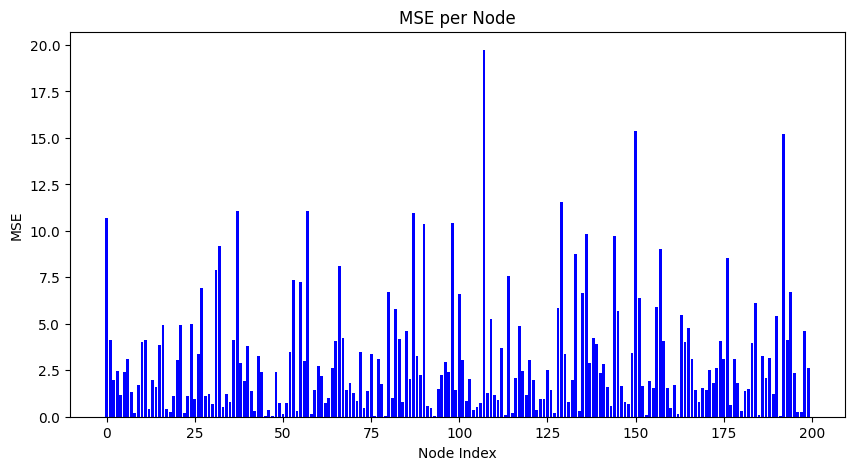

In [27]:
model.eval()
with torch.no_grad():
    pred = model(data)
    mse_per_node = ((pred - data.x) ** 2).mean(1).numpy()  # MSE per node

# Plotting MSE per node
plt.figure(figsize=(10, 5))
plt.bar(range(num_nodes), mse_per_node, color='blue')
plt.xlabel('Node Index')
plt.ylabel('MSE')
plt.title('MSE per Node')
plt.show()

# EKF_GSP

Arctangent Response:
Application: Similar to sigmoid but useful for phase measurements and applications where the response needs to be bounded within a specific range, like in angle measurements using gyroscopes.
Function:
𝑦
𝑡
=
𝐺
arctan
⁡
(
𝐻
𝑥
𝑡
)
y
t
​
 =Garctan(Hx
t
​
 )
Explanation:
𝐺
G and
𝐻
H scale the amplitude and the rate of change of the response. The arctangent naturally bounds the output, making it ideal for angles or normalized measurements.

In [29]:
def add_noise_based_on_snr(signal, snr_db):
    """ Adds noise to the signal based on the specified SNR in dB. """
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise

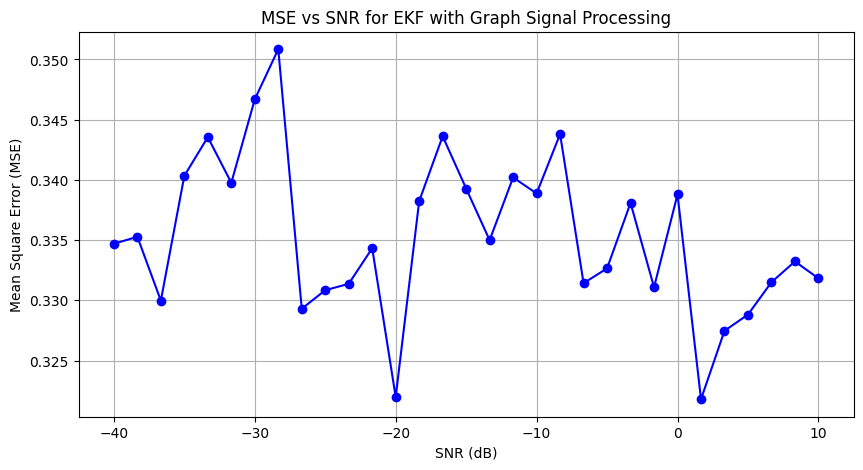

In [36]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def generate_initial_state(num_nodes):
    pressures = np.random.randn(num_nodes)  # Normally distributed pressures
    flows = np.random.randn(num_nodes)      # Normally distributed flows
    return np.vstack((pressures, flows)).flatten()  # State vector of pressures followed by flows

def state_transition(x, L, dt=0.0001):
    """ More physically plausible state transition model for pressures and flows """
    num_nodes = len(x) // 2
    pressures, flows = x[:num_nodes], x[num_nodes:]

    # Pressure diffusion model: pressure equalizes over the graph based on Laplacian
    d_pressures_dt = -L @ pressures

    # Flow model: flows change based on pressure gradients
    d_flows_dt = -L @ (pressures - np.mean(pressures))

    new_pressures = pressures + dt * d_pressures_dt
    new_flows = flows + dt * d_flows_dt
    return np.hstack((new_pressures, new_flows))

def measurement_model(x):
    """ Nonlinear measurement model """
    pressures, flows = x[:len(x)//2], x[len(x)//2:]
    # return np.hstack((np.arctan(pressures), np.arctan(flows)))  # Simplified measurement
    return np.hstack((pressures, flows))  # Simplified measurement

# Graph setup
num_nodes = 20
G = nx.random_tree(num_nodes)
L = nx.normalized_laplacian_matrix(G).toarray()  # Laplacian matrix

# Initialize state
x_true = generate_initial_state(num_nodes)
x_hat = np.random.randn(len(x_true))  # Initial estimate
P = np.eye(len(x_true))  # Initial covariance matrix

# Process and measurement noise covariances
Q = np.eye(len(x_true)) * 1  # Process noise covariance
R = np.eye(len(x_true)) * 2  # Measurement noise covariance

# SNR range and MSE storage
snr_range = np.linspace(-40, 10, 31)
mse_results = []

for snr_db in snr_range:
    x_hat = np.random.randn(len(x_true))  # Reset initial estimate for each SNR level
    P = np.eye(len(x_true))  # Reset initial error covariance
    mse = []

    for t in range(100):  # Simulate over time steps
        # Simulate system
        x_true = generate_initial_state(num_nodes) #state_transition(x_true, L)
        y = x_true + add_noise_based_on_snr(np.zeros(len(x_true)), snr_db)

        # EKF Prediction
        A = np.eye(len(x_true))  # Placeholder for the Jacobian of the state transition
        x_pred = state_transition(x_hat, L)
        P_pred = A @ P @ A.T + Q

        # EKF Update
        H = np.eye(len(x_true))  # Placeholder for the Jacobian of the measurement model
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x_hat = x_pred + K @ (y - measurement_model(x_pred))
        P = (np.eye(len(x_true)) - K @ H) @ P_pred

        # Calculate MSE
        mse.append(np.mean((x_true - x_hat)**2))

    mse_results.append(np.mean(mse))  # Average MSE over time for each SNR

# Plot MSE vs SNR
plt.figure(figsize=(10, 5))
plt.plot(snr_range, mse_results, marker='o', linestyle='-', color='blue')
plt.xlabel('SNR (dB)')
plt.ylabel('Mean Square Error (MSE)')
plt.title('MSE vs SNR for EKF with Graph Signal Processing')
plt.grid(True)
plt.savefig('/content/gdrive/My Drive/Colab Notebooks/GSP/figures/kalman.pdf', bbox_inches='tight')
plt.show()
